<a href="https://colab.research.google.com/github/aryaraut13/100-days-of-aiml/blob/main/day%204%20-%20stats" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mean:     50.19
Median:   50.25
Std Dev:  9.79
Variance: 95.79


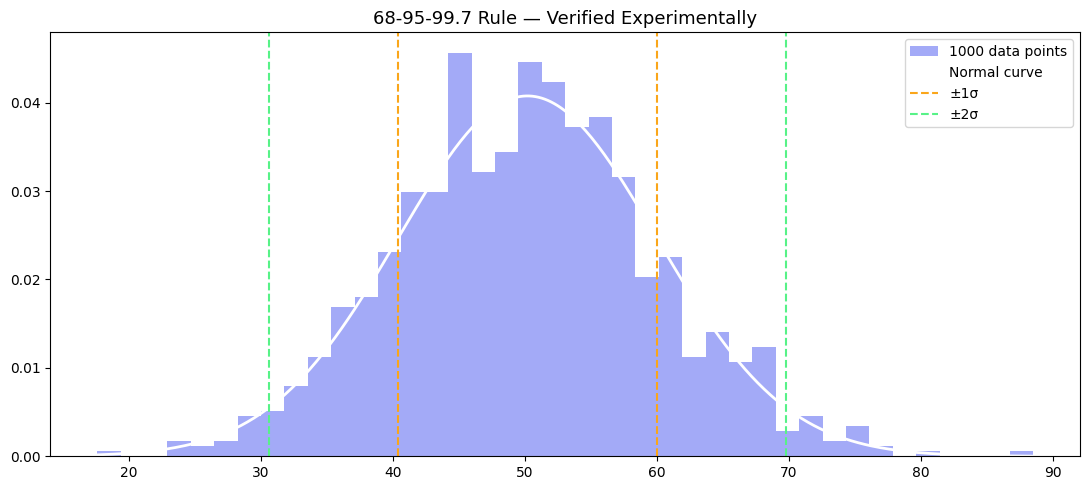


Within 1σ: 68.6%  (theory: 68%)
Within 2σ: 95.6%  (theory: 95%)

Where this matters in production:
→ Anomaly detection: flag anything beyond 3σ
→ Feature scaling: understand spread before normalising
→ Loss functions: MSE is literally variance


In [ ]:
# Day 04 — Statistics | 100 Days of AI/ML
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=1000)

mean, median = np.mean(data), np.median(data)
std, variance = np.std(data), np.var(data)

print(f"Mean:     {mean:.2f}")
print(f"Median:   {median:.2f}")
print(f"Std Dev:  {std:.2f}")
print(f"Variance: {variance:.2f}")

plt.figure(figsize=(11, 5))
plt.hist(data, bins=40, density=True, alpha=0.55, color="#5865F2", label="1000 data points")

x = np.linspace(data.min(), data.max(), 300)
plt.plot(x, stats.norm.pdf(x, mean, std), "w-", lw=2, label="Normal curve")

for i, c in zip([1, 2], ["#FAA61A", "#57F287"]):
    plt.axvline(mean + i*std, color=c, linestyle="--", lw=1.5, label=f"±{i}σ")
    plt.axvline(mean - i*std, color=c, linestyle="--", lw=1.5)

plt.legend()
plt.title("68-95-99.7 Rule — Verified Experimentally", fontsize=13)
plt.tight_layout()
plt.savefig("day04_stats.png", dpi=150)
plt.show()

w1 = np.mean(np.abs(data - mean) < std)   * 100
w2 = np.mean(np.abs(data - mean) < 2*std) * 100
print(f"\nWithin 1σ: {w1:.1f}%  (theory: 68%)")
print(f"Within 2σ: {w2:.1f}%  (theory: 95%)")
print("\nWhere this matters in production:")
print("→ Anomaly detection: flag anything beyond 3σ")
print("→ Feature scaling: understand spread before normalising")
print("→ Loss functions: MSE is literally variance")